In [1]:
import pandas as pd
import numpy as np

In [7]:
def mix_age_group(group):
    n = len(group)
    mean = group['auc_delong'].mean()
    # Since we're taking the average, divide combined variance by n^2
    var = group['auc_variance_delong'].sum() / (n**2)
    
    case_score = []
    for s in group['case_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        case_score.extend(s)
        
    control_score = []
    for s in group['control_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        control_score.extend(s)
        
    return pd.Series({
        'auc': mean,
        'auc_variance_delong': var,
        'n_groups': n, 
        'n_diseased': group['n_diseased'].sum(),
        'n_healthy': group['n_healthy'].sum(),
        'case_score': case_score,
        'control_score': control_score,
    })


In [2]:
import warnings

# Suppress only this specific warning
warnings.filterwarnings('ignore')

In [3]:

import matplotlib
import matplotlib.pyplot as plt
# Set Arial as the default font family
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


In [36]:
sum(y_true)

322.0

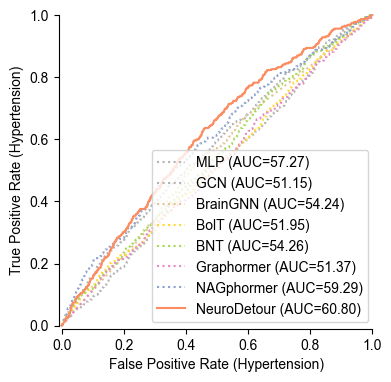

In [8]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score
cmap = matplotlib.colormaps['Set2']

rgba = cmap(0.5)
top_rowi = 432# pos_ratio.argmax()
fig, ax = plt.subplots(figsize=(4, 4))
# for k in auc_df_dict:
i = 0
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}.csv')
    # auc_df.index = auc_df['token']
    auc_df = auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()
    top_icd = auc_df[auc_df['token'].isin([top_rowi])]
    # avg, std = get_auc_delong_var(top_icd['control_score'].item(), top_icd['case_score'].item())
    y_true = np.zeros(len(top_icd['control_score'].item())).tolist()+np.ones(len(top_icd['case_score'].item())).tolist()
    y_score = top_icd['control_score'].item()+top_icd['case_score'].item()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_score = roc_auc_score(y_true, y_score)
    custom_label = f"{k} (AUC={auc_score*100:.2f})" 

    display = RocCurveDisplay.from_predictions(
        y_true, y_score, despine=True,# plot_chance_level=k == 'NeuroDetour', 
        ax=ax, name=k, color=cmap(1-i/8), label=custom_label, linestyle=':' if k!='NeuroDetour' else '-'
    )

    i += 1 
plt.tight_layout()
# plt.legend().remove()
plt.xlabel('False Positive Rate (Hypertension)')
plt.ylabel('True Positive Rate (Hypertension)')
# fig_legend = plt.figure(figsize=(3, 2))
# lines, labels = ax.get_legend_handles_labels()
# fig_legend.legend(lines, labels, loc='center')
# fig_legend.savefig("ICD_I10_ROC_legend.svg", bbox_inches='tight')
plt.savefig('ICD_I10_ROC.svg')

In [11]:
def mix_age_group(group):
    n = len(group)
    mean = group['auc_delong'].mean()
    # Since we're taking the average, divide combined variance by n^2
    var = group['auc_variance_delong'].sum() / (n**2)
    
    case_score = []
    for s in group['case_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        case_score.extend(s)
        
    control_score = []
    for s in group['control_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        control_score.extend(s)
        
    return pd.Series({
        'name': group['name'].iloc[0],
        'auc': mean,
        'auc_variance_delong': var,
        'n_groups': n, 
        'n_diseased': group['n_diseased'].sum(),
        'n_healthy': group['n_healthy'].sum(),
        'case_score': case_score,
        'control_score': control_score,
    })


In [4]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

In [5]:

pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}-grouped.csv').groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()

NameError: name 'k' is not defined

In [ ]:
all_auc_df

In [86]:

from sklearn.metrics import RocCurveDisplay, roc_curve, auc
# for k in auc_df_dict:
i = 0
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    all_auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}-grouped.csv')
    all_auc_df = all_auc_df[(all_auc_df['n_diseased']/all_auc_df['n_healthy'])>0.08]
    all_auc_df = all_auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()
    aucs = []
    for n in all_auc_df['name'].unique():
        auc_df = all_auc_df[all_auc_df['name']==n]
        y_true = np.zeros(len(auc_df['control_score'].item())).tolist()+np.ones(len(auc_df['case_score'].item())).tolist()
        y_score = auc_df['control_score'].item()+auc_df['case_score'].item()
        fpr, tpr, _ = roc_curve(y_true, y_score)
        score = auc(fpr, tpr)
        aucs.append(score)
    print(k, f'{np.mean(aucs)*100:.2f}+-{np.std(aucs)*100:.2f}')
# display = RocCurveDisplay.from_predictions(
#     y_true, y_score, despine=True, plot_chance_level=k == 'NeuroDetour', 
#     ax=ax, name=k, color=cmap(1-i/8)
# )

# i += 1 


MLP 52.48+-8.47
GCN 48.75+-4.01
BrainGNN 50.82+-2.62
BolT 47.51+-8.20
BNT 51.64+-5.62
Graphormer 49.63+-1.78
NAGphormer 47.84+-7.60
NeuroDetour 53.41+-10.14


0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225
0.10044977511244378
0.10596026490066225


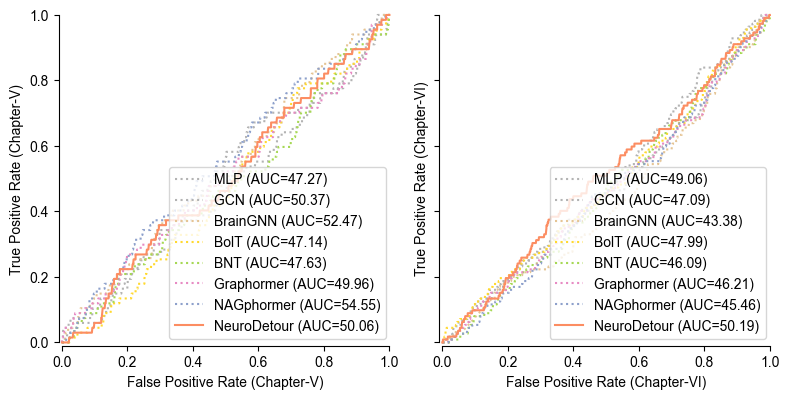

In [12]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
cmap = matplotlib.colormaps['Set2']

rgba = cmap(0.5)
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
i = 0
names = ['Chapter-V', 'Chapter-VI']
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    
    all_auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}-grouped.csv')
    all_auc_df = all_auc_df[(all_auc_df['n_diseased']/all_auc_df['n_healthy'])>0.08]
    all_auc_df = all_auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()
    # hc = all_auc_df[all_auc_df['name']=='Chapter-V']['control_score'].item() + all_auc_df[all_auc_df['name']=='Chapter-VI']['control_score'].item()
    # case = all_auc_df[all_auc_df['name']=='Chapter-V']['case_score'].item() + all_auc_df[all_auc_df['name']=='Chapter-VI']['case_score'].item()
    for ax, name in zip(axes, names):
        hc = all_auc_df[all_auc_df['name']==name]['control_score'].item()
        case = all_auc_df[all_auc_df['name']==name]['case_score'].item()
        print(len(case) / len(hc))
        y_true = np.zeros(len(hc)).tolist()+np.ones(len(case)).tolist()
        y_score = hc+case
        fpr, tpr, _ = roc_curve(y_true, y_score)
        # score = auc(fpr, tpr)
        # print(k, f'{np.mean(aucs)*100:.2f}+-{np.std(aucs)*100:.2f}')
        auc_score = roc_auc_score(y_true, y_score)
        custom_label = f"{k} (AUC={auc_score*100:.2f})" 
        display = RocCurveDisplay.from_predictions(
            y_true, y_score, despine=True, 
            ax=ax, name=k, color=cmap(1-i/8), label=custom_label, linestyle=':' if k!='NeuroDetour' else '-'
        )
        
        ax.set_xlabel(f'False Positive Rate ({name})')
        ax.set_ylabel(f'True Positive Rate ({name})')

# i += 1 

    i += 1 
plt.tight_layout()
# plt.legend().remove()
# plt.xlabel('False Positive Rate (Chapters V&VI)')
# plt.ylabel('True Positive Rate (Chapters V&VI)')
# fig_legend = plt.figure(figsize=(3, 2))
# lines, labels = ax.get_legend_handles_labels()
# fig_legend.legend(lines, labels, loc='center')
# fig_legend.savefig("ICD_I10_ROC_legend.svg", bbox_inches='tight')
plt.savefig('ICD_chapter_ROC.svg')

,token,auc,auc_variance_delong,n_groups,n_diseased,n_healthy,case_score,control_score
0,1,0.538791,0.000954,8,392,1578,"[0.5819934, 0.43131316, 0.4606083, 0.5139019, ...","[0.40623525, 0.31818584, 0.4274907, 0.5281104,..."
1,2,0.846154,0.018553,1,2,13,"[0.5838979, 0.22851138]","[0.5838979, 0.22851138, 0.17439647, 0.1457848,..."
2,3,0.505907,0.001166,6,247,1130,"[0.91722536, 0.772924, 0.77509403, 0.81402105,...","[0.80603313, 0.72135025, 0.8109325, 0.7906384,..."
3,4,0.529971,0.000810,8,501,1484,"[0.8771843, 0.86803937, 0.7748209, 0.82159084,...","[0.8771843, 0.86803937, 0.8662891, 0.85438615,..."
4,5,0.535329,0.003047,1,35,315,"[0.56641716, 0.6077747, 0.6017481, 0.62170035,...","[0.71714705, 0.59032315, 0.674916, 0.78885835,..."
5,6,0.453967,0.001455,2,67,583,"[0.43925256, 0.1999323, 0.38780478, 0.26736704...","[0.39067736, 0.20996553, 0.30366176, 0.1940234..."
6,7,0.458028,0.002261,5,168,791,"[0.36727607, 0.16807412, 0.2215243, 0.13016379...","[0.1850379, 0.16440749, 0.36727607, 0.16807412..."
7,9,0.488548,0.000719,7,180,1387,"[0.14244556, 0.243646, 0.3312862, 0.25555107, ...","[0.34410107, 0.34132794, 0.30127546, 0.3539108..."
8,10,0.499732,0.000012,8,615,1393,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 0.9988669, 1.0, 1.0, 1.0, 1.0, 1.0,..."
9,11,0.607534,0.002998,3,50,457,"[0.08615337, 0.11416376, 0.17777543, 0.1115728...","[0.05560498, 0.09324617, 0.02728415, 0.1125157..."


In [56]:
for n in auc_df['name'].unique():
    print(n, auc_df[auc_df['name']==n]['auc'].mean(), auc_df[auc_df['name']==n]['auc'].std())
    # break

Chapter-III 0.8461538 nan
Chapter-V 0.5353288 nan
Chapter-VI 0.45396685000000003 0.08988607052154964
Chapter-XII 0.6075342 0.13678862730099314
Chapter-XIX 0.537463026 0.11909775905131792
Chapter-XX 0.47499749714285716 0.07289119770530748
Chapter-VII 0.458028172 0.11159413644019975
Chapter-X 0.48854804428571436 0.15038096305358611
Chapter-IV 0.505906715 0.05398173942607027
Chapter-XIV 0.52800550375 0.11733940965631658
Chapter-II 0.53879145 0.07389456297088036
Chapter-XIII 0.5070674774999999 0.049733620324845726
Chapter-IX 0.52997119125 0.04923996583202115
Chapter-XVIII 0.53873767125 0.07602834809910208
Chapter-XI 0.49973167500000004 0.007871568827018267
Chapter-XXI 0.5029377175 0.03383671250581692


In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay, roc_curve
cmap = matplotlib.colormaps['Set2']

rgba = cmap(0.5)
top_rowi = 432# pos_ratio.argmax()
fig, ax = plt.subplots(figsize=(4, 4))
# for k in auc_df_dict:
i = 0
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}-grouped.csv')
    auc_df = auc_df[(auc_df['n_diseased']/auc_df['n_healthy'])>0.1]
    # auc_df.index = auc_df['token']
    auc_df = auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()
    top_icd = auc_df[auc_df['token'].isin([top_rowi])]
    # avg, std = get_auc_delong_var(top_icd['control_score'].item(), top_icd['case_score'].item())
    y_true = np.zeros(len(top_icd['control_score'].item())).tolist()+np.ones(len(top_icd['case_score'].item())).tolist()
    y_score = top_icd['control_score'].item()+top_icd['case_score'].item()
    fpr, tpr, _ = roc_curve(y_true, y_score)

    display = RocCurveDisplay.from_predictions(
        y_true, y_score, despine=True, plot_chance_level=k == 'NeuroDetour', 
        ax=ax, name=k, color=cmap(1-i/8)
    )

    i += 1 
plt.tight_layout()
plt.legend().remove()
plt.xlabel('False Positive Rate (Hypertension)')
plt.ylabel('True Positive Rate (Hypertension)')
# fig_legend = plt.figure(figsize=(3, 2))
# lines, labels = ax.get_legend_handles_labels()
# fig_legend.legend(lines, labels, loc='center')
# fig_legend.savefig("ICD_I10_ROC_legend.svg", bbox_inches='tight')
plt.savefig('ICD_I10_ROC.svg')

In [3]:
import torch

In [18]:
from scipy.stats import pearsonr
import numpy as np

In [28]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [39]:
gt.max()

3

In [47]:
beh_fns = [
    'ICD_NeuroDetourSingleD-beh_out.pth',
    'baseline_BNT-beh_out.pth',
    'baseline_BolT-beh_out.pth',
    'baseline_BrainGNN-beh_out.pth',
    'baseline_GCN-beh_out.pth',
    'baseline_Graphormer-beh_out.pth',
    'baseline_MLP-beh_out.pth',
    'baseline_NAGphormer-beh_out.pth',
]
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, mean_squared_error
table = {}
index = []
task2bincount = {}
for beh_fn in beh_fns:
    out = torch.load(f'mia-exp_eval_out/{beh_fn}', weights_only=False)
    mn = beh_fn.split('_')[1].split('-')[0]
    if mn not in table: table[mn] = []
    for k in out:
        if len(out[k]) == 0: continue
        if k not in index: index.append(k)
        if k not in task2bincount: task2bincount[k] = []
            
        metrices = []
        for ys in out[k]:
            gt = ys['y_true']
            score = ys['y_scores']
            if score.shape[1] > 1:
                acc = accuracy_score(gt, score.argmax(1))
                prec, rec, f1, _ = precision_recall_fscore_support(gt, score.argmax(1), average='weighted')
                metric = [acc*100, f1*100]
                is_mse = 'acc'
                bincount = np.bincount(gt)
                
            else:
                mse = mean_squared_error(gt, score[:, 0])
                r, p = pearsonr(gt, score[:, 0])
                metric = [mse, r]
                is_mse = 'mse'
                bincount = np.histogram(gt, bins=4)[0]
            
            metrices.append(metric)

        task2bincount[k].append(bincount)
        metrices = np.array(metrices)
        if is_mse == 'acc':
            table[mn].append(f'{metrices.mean(0)[0]:.2f}+-{metrices.std(0)[0]:.2f} & {metrices.mean(0)[1]:.2f}+-{metrices.std(0)[1]:.2f}')
        else:
            table[mn].append(f'{metrices.mean(0)[0]:.3f}+-{metrices.std(0)[0]:.3f} & {metrices.mean(0)[1]:.3f}+-{metrices.std(0)[1]:.3f}')
        if mn == 'NeuroDetourSingleD':
            print(f'{mn}\t{k} \t\t {is_mse} {metrices.mean(0)[0]:.2f}+-{metrices.std(0)[0]:.2f} \t {metrices.mean(0)[1]:.2f}+-{metrices.std(0)[1]:.2f}')
        else:
            print(f'{mn}\t\t\t{k} \t\t {is_mse} {metrices.mean(0)[0]:.2f}+-{metrices.std(0)[0]:.2f} \t {metrices.mean(0)[1]:.2f}+-{metrices.std(0)[1]:.2f}')
for k in task2bincount:
    print(k, np.array(task2bincount[k]).mean(0).sum(), np.array(task2bincount[k]).mean(0).tolist())
table = pd.DataFrame(table)
table.index = index

NeuroDetourSingleD	num_mem_acc 		 mse 0.01+-0.00 	 -0.01+-0.02
NeuroDetourSingleD	fluid_intel 		 acc 87.60+-0.43 	 87.60+-0.42
NeuroDetourSingleD	trail_error 		 acc 92.04+-0.30 	 91.83+-0.32
NeuroDetourSingleD	puzzle_solved 		 acc 87.61+-0.40 	 87.61+-0.40
NeuroDetourSingleD	symbol-digit_match 		 mse 28.63+-0.75 	 0.00+-0.02
NeuroDetourSingleD	vocab_level 		 mse 0.01+-0.00 	 0.02+-0.02
NeuroDetourSingleD	tower_game 		 mse 10.02+-0.16 	 0.01+-0.02
NeuroDetourSingleD	word_match 		 mse 6.73+-0.07 	 0.02+-0.02
NeuroDetourSingleD	alcohol_freq 		 acc 88.96+-0.52 	 88.94+-0.53
NeuroDetourSingleD	smoking 		 acc 100.00+-0.00 	 100.00+-0.00
NeuroDetourSingleD	sleepless 		 acc 91.11+-0.66 	 91.10+-0.67
BNT			num_mem_acc 		 mse 0.01+-0.00 	 0.04+-0.03
BNT			fluid_intel 		 acc 25.73+-2.79 	 16.56+-3.02
BNT			trail_error 		 acc 57.47+-1.39 	 41.96+-1.66
BNT			puzzle_solved 		 acc 23.96+-1.03 	 15.58+-2.04
BNT			symbol-digit_match 		 mse 28.78+-1.06 	 0.12+-0.01
BNT			vocab_level 		 mse 0.01+-0.00 	 

In [43]:
task2bincount[k]

[(array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32)),
 (array([  28, 2638,    0,    8]),
  array([0.     , 0.46875, 0.9375 , 1.40625, 1.875  ], dtype=float32))]

In [36]:
print(table.rename(columns={'NeuroDetourSingleD': 'NeuroDetour'})[['MLP','GCN','BrainGNN','BolT','BNT','Graphormer','NAGphormer','NeuroDetour']].to_markdown())

|                    | MLP                             | GCN                           | BrainGNN                      | BolT                         | BNT                          | Graphormer                     | NAGphormer                    | NeuroDetour                  |
|:-------------------|:--------------------------------|:------------------------------|:------------------------------|:-----------------------------|:-----------------------------|:-------------------------------|:------------------------------|:-----------------------------|
| num_mem_acc        | 0.313+-0.210 & 0.013+-0.023     | 0.039+-0.013 & 0.037+-0.013   | 0.164+-0.251 & -0.014+-0.025  | 0.030+-0.012 & 0.020+-0.015  | 0.011+-0.002 & 0.039+-0.025  | 0.018+-0.002 & 0.004+-0.017    | 0.014+-0.003 & 0.014+-0.011   | 0.012+-0.002 & -0.008+-0.016 |
| fluid_intel        | 66.97+-3.14 & 67.26+-2.88       | 20.60+-0.92 & 8.11+-0.62      | 24.27+-12.01 & 18.45+-13.11   | 20.55+-0.63 & 9.38+-1.29     | 25.73+-2.79

In [118]:
df = pd.read_pickle('data/ukb-nimg-dwi_icd10-beh_dated_flashattn3env.pkl')
df

,FC,FC_name,FC_date,FC_age (days),ICD10,ICD10_date,ICD10_age (days),Dementia,Dementia_date,Dementia_age (days),...,trail_error,puzzle_solved,symbol-digit_match,broken_letter,vocab_level,tower_game,word_match,alcohol_freq,smoking,sleepless
1000026,"[[[0.9999999999999998, 0.4031736535288627, -0....",[sub-1000026_ses-2_task-hariri_space-MNI152NLi...,"[2015-07-30, 2015-07-30]","[25869, 25869]","[B980, D509, E780, E785, I10, I209, I251, J449...","[2021-09-29, 2021-09-29, 2016-02-29, 2016-05-0...","[28122, 28122, 26083, 26148, 26083, 26148, 260...",NaN,NaN,NaN,...,"[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[2.0, 2.0]","[1.0, 1.0]","[3.0, 3.0]"
1000060,"[[[1.0, 0.6881473554050561, 0.1495016350062409...",[sub-1000060_ses-2_task-rest_space-MNI152NLin2...,"[2019-03-14, 2019-03-14]","[22109, 22109]","[D259, F419, G442, H268, I10, I441, K149, M179...","[2009-12-29, 2021-11-01, 2021-11-01, 2018-02-0...","[18747, 23072, 23072, 21711, 23072, 16061, 231...","[F419, G442]","[2021-11-01, 2021-11-01]","[23072, 23072]",...,"[0.0, 0.0]","[6.0, 6.0]","[20.0, 20.0]","[nan, nan]","[0.3203, 0.3203]","[8.0, 8.0]","[4.0, 4.0]","[1.0, 1.0]","[0.0, 0.0]","[2.0, 2.0]"
1000102,"[[[1.0, 0.6343429578599622, -0.024345747736203...",[sub-1000102_ses-2_task-rest_space-MNI152NLin2...,[2018-12-10],[23872],NaN,NaN,NaN,NaN,NaN,NaN,...,[3.0],[11.0],[19.0],[nan],[0.4409],[9.0],[7.0],[2.0],[0.0],[2.0]
1000139,"[[[1.0, 0.4480083117065995, 0.0640363923898662...",[sub-1000139_ses-2_task-rest_space-MNI152NLin2...,[2016-06-01],[28156],"[C329, D172, E780, F101, G409, H269, I252, I25...","[2010-03-29, 2010-03-29, 2007-09-17, 2018-08-1...","[25900, 25900, 24976, 28957, 22613, 24168, 289...","[F101, G409]","[2018-08-11, 2001-03-29]","[28957, 22613]",...,[nan],[nan],[nan],[nan],[nan],[nan],[nan],[3.0],[1.0],[2.0]
1000195,"[[[0.9999999999999998, 0.745800988424655, -0.3...",[sub-1000195_ses-2_task-hariri_space-MNI152NLi...,"[2018-01-18, 2018-01-18, 2021-05-26, 2021-05-26]","[19528, 19528, 20752, 20752]",NaN,NaN,NaN,NaN,NaN,NaN,...,"[0.0, 0.0, 0.0, 0.0]","[8.0, 8.0, 8.0, 8.0]","[27.0, 27.0, 27.0, 27.0]","[nan, nan, nan, nan]","[0.5727, 0.5727, 0.5727, 0.5727]","[14.0, 14.0, 14.0, 14.0]","[9.0, 9.0, 9.0, 9.0]","[1.0, 1.0, 1.0, 1.0]","[0.0, 0.0, 0.0, 0.0]","[2.0, 2.0, 2.0, 2.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6022695,"[[[1.0, 0.6620686434691022, -0.033311913605021...",[sub-6022695_ses-2_task-rest_space-MNI152NLin2...,"[2019-05-18, 2019-05-18]","[19495, 19495]","[K589, R101, R798, Z886]","[2022-03-25, 2022-03-25, 2022-03-25, 2022-03-25]","[20537, 20537, 20537, 20537]",NaN,NaN,NaN,...,"[0.0, 0.0]","[10.0, 10.0]","[27.0, 27.0]","[nan, nan]","[0.3957, 0.3957]","[11.0, 11.0]","[9.0, 9.0]","[3.0, 3.0]","[0.0, 0.0]","[1.0, 1.0]"
6022820,"[[[1.0, -0.0482714016850907, 0.308886073715980...",[sub-6022820_ses-2_task-hariri_space-MNI152NLi...,"[2015-06-01, 2015-06-01]","[22372, 22372]",NaN,NaN,NaN,NaN,NaN,NaN,...,"[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[2.0, 2.0]","[0.0, 0.0]","[2.0, 2.0]"
6022900,"[[[1.0, 0.6585386095856742, 0.0177694108469557...",[sub-6022900_ses-2_task-hariri_space-MNI152NLi...,"[2019-10-02, 2019-10-02]","[24655, 24655]",[H431],[2015-02-09],[22959],NaN,NaN,NaN,...,"[2.0, 2.0]","[8.0, 8.0]","[18.0, 18.0]","[nan, nan]","[0.3884, 0.3884]","[5.0, 5.0]","[9.0, 9.0]","[2.0, 2.0]","[0.0, 0.0]","[1.0, 1.0]"
6022917,"[[[1.0, 0.39577623816855567, -0.34633554747819...",[sub-6022917_ses-2_task-rest_space-MNI152NLin2...,[2018-08-25],[22031],"[I846, K509, K621, K623, K625, K628, K639, K90...","[2000-09-04, 2004-12-06, 2017-07-11, 2019-12-3...","[15467, 17021, 21621, 22524, 16026, 15467, 156...",NaN,NaN,NaN,...,[2.0],[8.0],[23.0],[nan],[0.2896],[10.0],[7.0],[6.0],[0.0],[2.0]


In [120]:
x = []
for l in df['trail_error']:
    x.extend(l)

print(len(x))

50906


In [122]:
np.unique(x)

(62,)

In [254]:
sc_th = [0.1, 0.3, 0.5]
out=['adni\n\
Mean Accuracy: 0.8348, Std Accuracy: 0.0531 \n\
Mean F1 Score: 77.35, Std F1 Score: 7.35 \n\
hcpa\n\
Mean Accuracy: 95.03, Std Accuracy: 1.93 \n\
Mean F1 Score: 95.09, Std F1 Score: 1.86\n\
oasis\n\
Mean Accuracy: 89.02, Std Accuracy: 3.48\n\
Mean F1 Score: 87.02, Std F1 Score: 3.77\n\
ukb\n\
Mean Accuracy: 99.59, Std Accuracy: 0.21\n\
Mean F1 Score: 99.59, Std F1 Score: 0.21',
'adni\n\
Mean Accuracy: 0.8148148148148149, Std Accuracy: 0.08685954660177231\n\
Mean F1 Score: 0.7776009804888139, Std F1 Score: 0.0851082056760788\n\
hcpa\n\
Mean Accuracy: 0.9757209466009765, Std Accuracy: 0.002218226669356227\n\
Mean F1 Score: 0.9756486671833089, Std F1 Score: 0.002404680009931326\n\
oasis\n\
Mean Accuracy: 0.8877922077922078, Std Accuracy: 0.03573906049132347\n\
Mean F1 Score: 0.852627338063656, Std F1 Score: 0.04560259357094765\n\
ukb\n\
Mean Accuracy: 0.9964518317973152, Std Accuracy: 0.0012902956223115325\n\
Mean F1 Score: 0.9964522427143357, Std F1 Score: 0.001289630657993257',
'adni\n\
Mean Accuracy: 0.8207407407407408, Std Accuracy: 0.06857354938983917\n\
Mean F1 Score: 0.7594144413320884, Std F1 Score: 0.09399525076150894\n\
hcpa\n\
Mean Accuracy: 0.9759045082599217, Std Accuracy: 0.005766939837485552\n\
Mean F1 Score: 0.9757107809453167, Std F1 Score: 0.005929939448833466\n\
oasis\n\
Mean Accuracy: 0.8924567099567099, Std Accuracy: 0.033874355256557465\n\
Mean F1 Score: 0.8673319431161566, Std F1 Score: 0.034308530390262604\n\
ukb\n\
Mean Accuracy: 0.9964469149311579, Std Accuracy: 0.000957856304012239\n\
Mean F1 Score: 0.9964471473585709, Std F1 Score: 0.0009576824377290905']

In [255]:
out[0]

'adni\nMean Accuracy: 0.8348, Std Accuracy: 0.0531 \nMean F1 Score: 77.35, Std F1 Score: 7.35 \nhcpa\nMean Accuracy: 95.03, Std Accuracy: 1.93 \nMean F1 Score: 95.09, Std F1 Score: 1.86\noasis\nMean Accuracy: 89.02, Std Accuracy: 3.48\nMean F1 Score: 87.02, Std F1 Score: 3.77\nukb\nMean Accuracy: 99.59, Std Accuracy: 0.21\nMean F1 Score: 99.59, Std F1 Score: 0.21'

In [256]:
accs, f1s, dns, sc_ths = [], [], [], []
for t, lines in zip(sc_th, out):
    
    for i, line in enumerate(lines.split('\n')):
        if i % 3 == 0 and i >= 3:
            # print(dn, acc, f1)
            f1s.append(f1)
            dns.append(dn.upper())
            accs.append(acc)
            sc_ths.append(t)
        if i % 3 == 0: 
            dn = line
        elif i % 3 == 2:
            f1 = float(line.split(', ')[0].split(' ')[-1])
            if f1 < 1: f1 = f1 * 100
        else:
            acc = float(line.split(', ')[0].split(' ')[-1])
            if acc < 1: acc = acc * 100
    # print(dn, acc, f1)
    f1s.append(f1)
    dns.append(dn.upper())
    accs.append(acc)
    sc_ths.append(t)


import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
cmap = matplotlib.colormaps['tab10']

data = {
    'Acc': accs,
    'F1 score': f1s,
    'SC threshold': sc_ths,
    'Data': dns,
}

data = pd.DataFrame(data)
data
# plt.figure(figsize=(6,1.5))
# plt.grid()
# ax = sns.scatterplot(data=data, y='SC threshold', x='F1 score', hue='Data', marker='o', s=500, legend=False)
# plt.ylim(0, 0.6)
# plt.yticks([0.1, 0.3, 0.5])
# plt.tight_layout()
# plt.savefig(f'mia_logs/lineplot_ablation_scth.svg')

,Acc,F1 score,SC threshold,Data
0,83.480000,77.350000,0.1,ADNI
1,95.030000,95.090000,0.1,HCPA
2,89.020000,87.020000,0.1,OASIS
3,99.590000,99.590000,0.1,UKB
4,81.481481,77.760098,0.3,ADNI
5,97.572095,97.564867,0.3,HCPA
6,88.779221,85.262734,0.3,OASIS
7,99.645183,99.645224,0.3,UKB
8,82.074074,75.941444,0.5,ADNI
9,97.590451,97.571078,0.5,HCPA


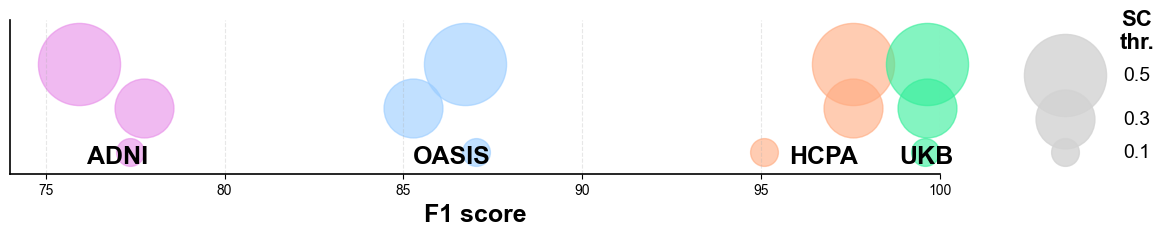

In [153]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# Data (example values from your image)
# -------------------------------------------------------
datasets = data['Data'].unique().tolist()

f1 = {
    dn:  data[data['Data']==dn]['F1 score'].tolist() for dn in datasets
}

sc = {    
    dn:  data[data['Data']==dn]['SC threshold'].tolist() for dn in datasets
}

colors = {
    "ADNI":  "#E78CE8",   # pastel pink
    "OASIS": "#99CCFF",   # pastel blue
    "HCPA":  "#FFAA7F",   # pastel orange
    "UKB":   "#33EE99",   # pastel green
}

# bubble size mapping: area ∝ SC threshold
size_map = {0.1: 400, 0.3: 1800, 0.5: 3500}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure(figsize=(12, 2))
ax = plt.gca()

# draw bubbles for each dataset
for name in datasets:
    for x, y in zip(f1[name], sc[name]):
        ax.scatter(
            x, y,
            s=size_map[y],
            color=colors[name],
            edgecolor=colors[name],
            linewidth=1,
            alpha=0.6,clip_on=False
        )

# -------------------------------------------------------
# Labeling datasets below the points
# -------------------------------------------------------
for name in datasets:
    xs = f1[name]
    ys = sc[name]
    ax.text(
        np.mean(xs), min(ys) + 0.03,
        name, ha='center', va='top',
        fontsize=18, fontweight='bold'
    )

# -------------------------------------------------------
# Axis style
# -------------------------------------------------------
ax.set_xlabel("F1 score", fontsize=18, fontweight='bold')
ax.set_xlim(74, 100)
ax.set_ylim(0.0, 0.7)
ax.set_ylabel("")
ax.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# light vertical grid like in image
ax.grid(axis='x', linestyle='--', alpha=0.3)

# -------------------------------------------------------
# Bubble legend on the right
# -------------------------------------------------------
legend_sizes = [0.5, 0.3, 0.1]
legend_y = [0.45, 0.25, 0.10]

for s, y in zip(legend_sizes, legend_y):
    ax.scatter(
        103.5, y,
        s=size_map[s],
        color="lightgray",
        edgecolor="lightgray",
        linewidth=1,
        alpha=0.8,clip_on=False
    )

ax.text(105.5, 0.65, "SC\nthr.", ha='center', va='center',
        fontsize=16, fontweight="bold")

ax.text(105.5, 0.45, "0.5", ha='center', va='center', fontsize=14)
ax.text(105.5, 0.25, "0.3", ha='center', va='center', fontsize=14)
ax.text(105.5, 0.10, "0.1", ha='center', va='center', fontsize=14)
plt.margins(x=0.02)
# plt.tight_layout()
plt.show()



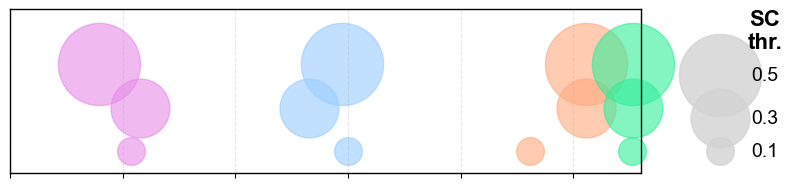

In [262]:

# -------------------------------------------------------
# Data (example values from your image)
# -------------------------------------------------------
datasets = data['Data'].unique().tolist()

f1 = {
    dn:  data[data['Data']==dn]['F1 score'].tolist() for dn in datasets
}

sc = {    
    dn:  data[data['Data']==dn]['SC threshold'].tolist() for dn in datasets
}

colors = {
    "ADNI":  "#E78CE8",   # pastel pink
    "OASIS": "#99CCFF",   # pastel blue
    "HCPA":  "#FFAA7F",   # pastel orange
    "UKB":   "#33EE99",   # pastel green
}

# bubble size mapping: area ∝ SC threshold
size_map = {0.1: 400, 0.3: 1800, 0.5: 3500}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
plt.figure(figsize=(8, 2))
ax = plt.gca()
# draw bubbles for each dataset
for name in datasets:
    for x, y in zip(f1[name], sc[name]):
        ax.scatter(
            x, y,
            s=size_map[y],
            color=colors[name],
            edgecolor=colors[name],
            linewidth=1,
            alpha=0.6,clip_on=False
        )
xs = []
ys = []
# # -------------------------------------------------------
# # Labeling datasets below the points
# # -------------------------------------------------------
for name in datasets:
    xs += f1[name]
    ys += sc[name]
#     ax.text(
#         np.max(xs), max(ys) + 0.03,
#         name, ha='center', va='top',
#         fontsize=18, fontweight='bold'
#     )

# -------------------------------------------------------
# Axis style
# -------------------------------------------------------
# ax.set_xlabel("F1 score", fontsize=18, fontweight='bold')
ax.set_xlim(72.5, 100)
ax.set_ylim(min(ys)-0.1, max(ys)+0.25
           )
ax.set_xticks(list(range(72,101,5)), ['' for _ in range(72,101,5)])
# ax.set_ylabel("")
ax.set_yticks([])
# ax.set_ylabel(models[axi])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# light vertical grid like in image
ax.grid(axis='x', linestyle='--', alpha=0.3)
# if models[axi] != 'Graphormer':
#     ax.tick_params(labelbottom=False)
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1)


# -------------------------------------------------------
# Bubble legend on the right
# -------------------------------------------------------
legend_sizes = [0.5, 0.3, 0.1]
legend_y = [0.45, 0.25, 0.10]

for s, y in zip(legend_sizes, legend_y):
    ax.scatter(
        103.5, y,
        s=size_map[s],
        color="lightgray",
        edgecolor="lightgray",
        linewidth=1,
        alpha=0.8,clip_on=False
    )

ax.text(105.5, 0.65, "SC\nthr.", ha='center', va='center',
        fontsize=16, fontweight="bold")

ax.text(105.5, 0.45, "0.5", ha='center', va='center', fontsize=14)
ax.text(105.5, 0.25, "0.3", ha='center', va='center', fontsize=14)
ax.text(105.5, 0.10, "0.1", ha='center', va='center', fontsize=14)
    
plt.margins(x=0.02,  y=0.1)
plt.tight_layout()
plt.savefig(f'bubbleplot_ablation_scth.svg')
plt.show()

In [272]:
models = ['BNT','BolT','Graphormer','NAGphormer','$NeuroDetour$']
layers = [4,8,16]

datan = []
layern = []
mn = []
f1 = []

f1+=[91.81,\
93.41,\
93.28,\
97.01,\
97.81,\
88.23,\
64.08,\
47.01,\
50.84,\
96.89,\
97.26,\
97.22,\
97.76,\
97.72,\
96.60]
datan += ['hcpa'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])

f1+=[88.63,\
96.32,\
97.45,\
81.36,\
89.20,\
89.84,\
43.42,\
43.44,\
59.46,\
99.24,\
98.95,\
99.20,\
99.59,\
99.61,\
99.44]
datan += ['ukb'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])



f1+=[76.39,\
75.91,\
77.28,\
75.93,\
78.67,\
78.23,\
78.58,\
74.12,\
74.12,\
75.86,\
77.15,\
78.44,\
78.93,\
78.42,\
78.32]
datan += ['adni'.upper() for _ in range(15)]


for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])


f1+=[85.32,\
85.96,\
85.21,\
85.30,\
84.55,\
85.55,\
84.45,\
83.87,\
83.87,\
86.05,\
86.49,\
85.78,\
86.16,\
86.77,\
85.78]

datan += ['oasis'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])


data = pd.DataFrame({
    'F1 score': f1,
    'layer #': layern,
    'Model': mn,
    'Data': datan
})
data

,F1 score,layer #,Model,Data
0,91.81,4,BNT,HCPA
1,93.41,8,BNT,HCPA
2,93.28,16,BNT,HCPA
3,97.01,4,BolT,HCPA
4,97.81,8,BolT,HCPA
5,88.23,16,BolT,HCPA
6,64.08,4,Graphormer,HCPA
7,47.01,8,Graphormer,HCPA
8,50.84,16,Graphormer,HCPA
9,96.89,4,NAGphormer,HCPA


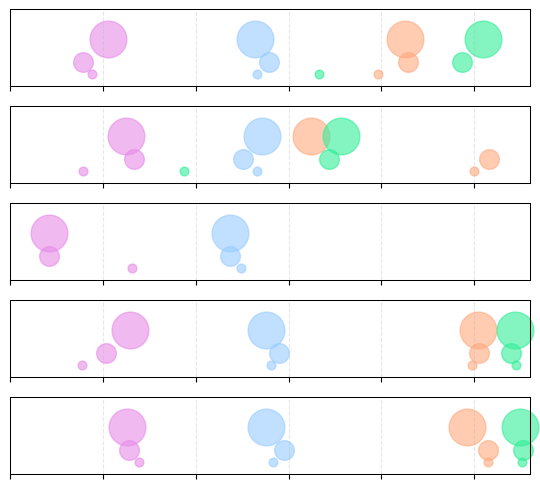

In [273]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# Data (example values from your image)
# -------------------------------------------------------
datasets = data['Data'].unique().tolist()

colors = {
    "ADNI":  "#E78CE8",   # pastel pink
    "OASIS": "#99CCFF",   # pastel blue
    "HCPA":  "#FFAA7F",   # pastel orange
    "UKB":   "#33EE99",   # pastel green
}

# bubble size mapping: area ∝ SC threshold
# size_map = {0.1: 400, 0.3: 1800, 0.5: 3500}
size_map = {4: 40, 8: 200, 16: 700}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
hyperparam = 'layer #'
fig, axes = plt.subplots(len(models), 1, figsize=(5.5, len(models)), sharex=True)

for axi, ax in enumerate(axes):
        
    f1 = {
        dn:  data[data['Data']==dn][data['Model']==models[axi]]['F1 score'].tolist() for dn in datasets
    }
    
    sc = {    
        dn:  data[data['Data']==dn][data['Model']==models[axi]][hyperparam].tolist() for dn in datasets
    }

    # draw bubbles for each dataset
    for name in datasets:
        for x, y in zip(f1[name], sc[name]):
            ax.scatter(
                x, y,
                s=size_map[y],
                color=colors[name],
                edgecolor=colors[name],
                linewidth=1,
                alpha=0.6,clip_on=False
            )
    xs = []
    ys = []
    # # -------------------------------------------------------
    # # Labeling datasets below the points
    # # -------------------------------------------------------
    for name in datasets:
        xs += f1[name]
        ys += sc[name]
    #     ax.text(
    #         np.max(xs), max(ys) + 0.03,
    #         name, ha='center', va='top',
    #         fontsize=18, fontweight='bold'
    #     )
    
    # -------------------------------------------------------
    # Axis style
    # -------------------------------------------------------
    # ax.set_xlabel("F1 score", fontsize=18, fontweight='bold')
    ax.set_xlim(72.5, 100)
    ax.set_ylim(min(ys)-4, max(ys)+10
               )
    ax.set_xticks(list(range(72,101,5)), ['' for _ in range(72,101,5)])
    # ax.set_ylabel("")
    ax.set_yticks([])
    # ax.set_ylabel(models[axi])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # light vertical grid like in image
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    # if models[axi] != 'Graphormer':
    #     ax.tick_params(labelbottom=False)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.75)
# axes.flatten()[0].get_shared_x_axes().join(axes[0], axes[1], axes[3], axes[4])


# -------------------------------------------------------
# Bubble legend on the right
# -------------------------------------------------------
# legend_sizes = [16, 8, 4]
# legend_y = [0.45, 0.25, 0.10]

# for s, y in zip(legend_sizes, legend_y):
#     ax.scatter(
#         103.5, y,
#         s=size_map[s],
#         color="lightgray",
#         edgecolor="lightgray",
#         linewidth=1,
#         alpha=0.8,clip_on=False
#     )

# ax.text(105.5, 0.65, "SC\nthr.", ha='center', va='center',
#         fontsize=16, fontweight="bold")

# ax.text(105.5, 0.45, "0.5", ha='center', va='center', fontsize=14)
# ax.text(105.5, 0.25, "0.3", ha='center', va='center', fontsize=14)
# ax.text(105.5, 0.10, "0.1", ha='center', va='center', fontsize=14)
    
plt.margins(x=0.02,  y=0.1)
plt.tight_layout()
plt.savefig(f'bubbleplot_ablation_layern.svg')
plt.show()



In [266]:
layers = [0.3,0.5,0.7]

datan = []
layern = []
mn = []
f1 = []

f1+=[95.73,\
92.57,\
84.51,\
86.02,\
95.78,\
94.68,\
90.41,\
53.05,\
88.43,\
96.08,\
94.76,\
96.85,\
97.57,\
95.09,\
97.32]

datan += ['hcpa'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])

f1+=[76.41,\
98.64,\
94.46,\
86.98,\
99.29,\
87.04,\
97.76,\
86.54,\
96.73,\
97.80,\
99.22,\
98.78,\
99.27,\
99.59,\
99.15]
datan += ['ukb'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])



f1+=[77.74,\
80.16,\
77.92,\
74.33,\
76.68,\
76.53,\
75.82,\
77.78,\
75.17,\
72.55,\
75.40,\
77.29,\
78.36,\
77.35,\
79.49]
datan += ['adni'.upper() for _ in range(15)]


for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])


f1+=[85.14,\
85.32,\
86.05,\
84.98,\
84.91,\
84.67,\
86.23,\
85.44,\
87.15,\
86.32,\
83.87,\
85.78,\
86.59,\
87.02,\
86.13]


datan += ['oasis'.upper() for _ in range(15)]

for i in range(len(models)):
    layern.extend([l for l in  layers])
    mn.extend([models[i] for _ in range(len(layers))])


data = pd.DataFrame({
    'F1 score': f1,
    'FC threshold': layern,
    'Model': mn,
    'Data': datan
})
data

,F1 score,FC threshold,Model,Data
0,95.73,0.3,BNT,HCPA
1,92.57,0.5,BNT,HCPA
2,84.51,0.7,BNT,HCPA
3,86.02,0.3,BolT,HCPA
4,95.78,0.5,BolT,HCPA
5,94.68,0.7,BolT,HCPA
6,90.41,0.3,Graphormer,HCPA
7,53.05,0.5,Graphormer,HCPA
8,88.43,0.7,Graphormer,HCPA
9,96.08,0.3,NAGphormer,HCPA


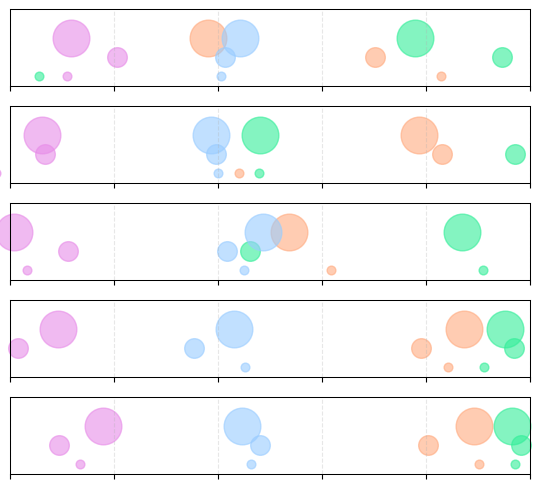

In [271]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# Data (example values from your image)
# -------------------------------------------------------
datasets = data['Data'].unique().tolist()

colors = {
    "ADNI":  "#E78CE8",   # pastel pink
    "OASIS": "#99CCFF",   # pastel blue
    "HCPA":  "#FFAA7F",   # pastel orange
    "UKB":   "#33EE99",   # pastel green
}

# bubble size mapping: area ∝ SC threshold
# size_map = {0.1: 400, 0.3: 1800, 0.5: 3500}
size_map = {0.3: 40, 0.5: 200, 0.7: 700}

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
hyperparam = 'FC threshold'
fig, axes = plt.subplots(len(models), 1, figsize=(5.5, len(models)), sharex=True)
for axi, ax in enumerate(axes):
        
    f1 = {
        dn:  data[data['Data']==dn][data['Model']==models[axi]]['F1 score'].tolist() for dn in datasets
    }
    
    sc = {    
        dn:  data[data['Data']==dn][data['Model']==models[axi]][hyperparam].tolist() for dn in datasets
    }

    # draw bubbles for each dataset
    for name in datasets:
        for x, y in zip(f1[name], sc[name]):
            ax.scatter(
                x, y,
                s=size_map[y],
                color=colors[name],
                edgecolor=colors[name],
                linewidth=1,
                alpha=0.6,clip_on=False
            )
    xs = []
    ys = []
    # # -------------------------------------------------------
    # # Labeling datasets below the points
    # # -------------------------------------------------------
    for name in datasets:
        xs += f1[name]
        ys += sc[name]
    #     ax.text(
    #         np.max(xs), max(ys) + 0.03,
    #         name, ha='center', va='top',
    #         fontsize=18, fontweight='bold'
    #     )
    
    # -------------------------------------------------------
    # Axis style
    # -------------------------------------------------------
    # ax.set_xlabel("F1 score", fontsize=18, fontweight='bold')
    ax.set_xlim(75, 100)
    ax.set_ylim(min(ys)-0.1, max(ys)+0.3)
    # ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xticks(list(range(75,101,5)), ['' for _ in range(75,101,5)])
    # ax.set_ylabel(models[axi])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # light vertical grid like in image
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.75)
# -------------------------------------------------------
# Bubble legend on the right
# -------------------------------------------------------
# legend_sizes = [16, 8, 4]
# legend_y = [0.45, 0.25, 0.10]

# for s, y in zip(legend_sizes, legend_y):
#     ax.scatter(
#         103.5, y,
#         s=size_map[s],
#         color="lightgray",
#         edgecolor="lightgray",
#         linewidth=1,
#         alpha=0.8,clip_on=False
#     )

# ax.text(105.5, 0.65, "SC\nthr.", ha='center', va='center',
#         fontsize=16, fontweight="bold")

# ax.text(105.5, 0.45, "0.5", ha='center', va='center', fontsize=14)
# ax.text(105.5, 0.25, "0.3", ha='center', va='center', fontsize=14)
# ax.text(105.5, 0.10, "0.1", ha='center', va='center', fontsize=14)
    
plt.margins(x=0.02,  y=0.1)
plt.tight_layout()
plt.savefig(f'bubbleplot_ablation_fcth.svg')
plt.show()



ukbgordon [99.0023412626385, 99.0996743326784, 99.15121485490349, 99.11758747563117, 99.13419790739087, 99.15235045552983, 99.21884535423959, 99.18506161877684] [1, 2, 3, 4, 5, 6, 7, 8]
hcpagordon [97.1621521800991, 97.32566184917872, 97.22420291501157, 97.12029838146229, 97.34611199820236, 97.51389338086106, 97.86086617196854, 97.42794845212313] [1, 2, 3, 4, 5, 6, 7, 8]
adniaal [82.88888888888889, 79.77777777777779, 82.14814814814815, 82.0, 82.81481481481482, 82.81481481481482, 84.22222222222221, 80.66666666666666] [1, 2, 3, 4, 5, 6, 7, 8]
oasis [89.78679653679654, 89.05086580086581, 88.99567099567098, 89.48376623376623, 88.22835497835499, 88.79112554112554, 89.32034632034632, 87.72835497835499] [1, 2, 3, 4, 5, 6, 7, 8]


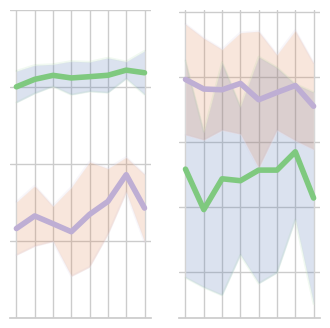

In [345]:
import os
logtag = ''
def ablation_plot(tgtdn, tgtmetric, ax, yticks):
    tgtdt = 'statfcFC'
    res = {}
    for logf in os.listdir(f'{logtag}logs'):
        if not logf.endswith('.log'): continue
        with open(f'{logtag}logs/{logf}', 'r') as f:
            lines = f.read().split('\n')[-5:]
        if 'Mean' not in lines[0]: continue
        bb = logf.split('_')[0]
        if 'H1L' not in bb: 
            continue
        
        # cls = logf.split('_')[1]
        
        dn = logf.split('_')[2]
        dt = ' '.join(logf.split('_')[3:]).replace('.log', '')
        dt = ''.join([i for i in dt if not i.isdigit()]).replace('-', '')
        if tgtdt not in dt: continue
        if bb not in res:
            res[bb] = []
        acc_avg = float(lines[0].split('Accuracy: ')[1].replace(', Std ', ''))
        acc_std = float(lines[0].split('Accuracy: ')[2])
        f1_avg = float(lines[1].split('F1 Score: ')[1].replace(', Std ', ''))
        f1_std = float(lines[1].split('F1 Score: ')[2])
        
        
        res[bb].append((dt, acc_avg*100, f1_avg*100, acc_std*100, f1_std*100, dn))

    data = {
        'Heads': [],
        'Scores': [],
        'std': [],
        'Data': []
    }
    for bb in res:
        headn = int(bb.split('H1L')[0][-1])
        for r in res[bb]:
            dn = r[-1]+r[0].split(' ')[1]
            data['Heads'].append(headn)
            data['Scores'].append(r[tgtmetric])
            data['std'].append(r[tgtmetric+2])
            data['Data'].append(dn)
            
        
    data = pd.DataFrame(data) 
    
    # print(data)  
    import seaborn as sns
    import numpy as np
    import matplotlib
    # Draw plot with error band and extra formatting to match seaborn style
    cmap = matplotlib.colormaps['Accent']
    ci = 0
    for dn in data['Data'].unique():
        if dn not in tgtdn: continue
        color = cmap(ci)
        ci += 1
        x = data[data['Data']==dn]['Heads']
        ind = np.argsort(list(x))
        x = x.to_numpy()[ind]
        y_mean = data[data['Data']==dn]['Scores'].to_numpy()[ind]
        error = data[data['Data']==dn]['std'].to_numpy()[ind]
        nx, ny_mean, nerror = [], [], []
        for xi in np.unique(x):
            nx.append(xi)
            if len(x[x==xi]) > 1:
                if xi == 1:
                    ny_mean.append(y_mean[x==xi].max().item())
                else:
                    ny_mean.append(y_mean[x==xi].min().item())
                nerror.append(error[x==xi].mean().item())
            else:
                ny_mean.append(y_mean[x==xi].item())
                nerror.append(error[x==xi].item())
            if xi == 1 and dn=='ukbgordon': ny_mean[-1] -= 0.2
        lower = np.array(ny_mean) - np.array(nerror)
        upper = np.array(ny_mean) + np.array(nerror)
        print(dn, ny_mean, nx)
        ax.plot(nx, ny_mean, label=dn, color=color, linewidth=4
               )
        ax.plot(nx, lower, color=color, alpha=0.1)
        ax.plot(nx, upper, color=color, alpha=0.1)
        ax.fill_between(nx, lower, upper, alpha=0.2)
    # ax.set_xlabel('heads')
    # ax.set_ylabel('scores')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_bounds(0, 10)
    ax.set_xticks(list(range(1,9)), ['' for _ in range(1,9)])
    ax.set_yticks(yticks, ['' for _ in yticks])
    # ax.grid(visible=True)
    # ax.set_title(str(tgtdn)+str(tgtmetric))
    
    return data

# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(2, 2, figsize=(8,4))
fig, axes = plt.subplots(1, 2, figsize=(4,4))

data1 = ablation_plot(['hcpagordon', 'ukbgordon'], 1, axes[0], list(range(96,101)))

data2 = ablation_plot(['adniaal', 'oasis'], 1, axes[1], list(range(75,96,5)))
plt.savefig('f1_vs_h.svg')
# data2 = ablation_plot(['adniaal'], 1, axes)
# data3 = ablation_plot(['oasis'], 1, axes)
# data4 = ablation_plot(['ukbgordon'], 1, axes)
# data1 = ablation_plot(['hcpagordon'], 1, axes[0, 0])
# data2 = ablation_plot(['adniaal'], 1, axes[1, 0])
# data3 = ablation_plot(['oasis'], 1, axes[1, 1])
# ablation_plot(['hcpaaal', 'hcpagordon'], 2, axes[0, 1])
# data4 = ablation_plot(['ukbgordon'], 1, axes[0, 1])
# # ablation_plot(['ukbaal', 'ukbgordon'], 2, axes[1, 1])

In [401]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

latex_table = r"""
\begin{tabular}{llllllllllll}
\toprule
      &                  & \multicolumn{2}{c}{HCPA CORR} & \multicolumn{2}{c}{HCPA BOLD} & \multirow{2}{*}{Rank $\downarrow$} & \multicolumn{2}{c}{UKB CORR} & \multicolumn{2}{c}{UKB BOLD} & \multirow{2}{*}{Rank $\downarrow$} \\\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){8-9}\cmidrule(lr){10-11}
    &               & static  & dynamic  & static & dynamic & & static & dynamic & static & dynamic  \\
\midrule
% $\bullet$ Accuracy $\uparrow$ \\
Acc. $\uparrow$ &    MLP & 96.01$_{\pm0.50}$ & 92.57$_{\pm0.32}$ &  93.42$_{\pm0.58}$ & 83.64$_{\pm1.33}$ & 4.00 &        99.00$_{\pm0.15}$ & {97.70$_{\pm0.32}$} &     99.05$_{\pm0.48}$ &   {96.42$_{\pm0.60}$} & 3.00\\
                    &GCN & 95.85$_{\pm0.93}$ & 91.95$_{\pm0.45}$ &  92.94$_{\pm0.58}$ & 84.60$_{\pm0.45}$ & 4.50 &  99.00$_{\pm0.22}$ & 97.54$_{\pm0.24}$ &      {99.31$_{\pm0.33}$} &   93.39$_{\pm0.71}$ & 3.75 \\%\midrule
               &BrainGNN & 90.85$_{\pm1.35}$ & 86.06$_{\pm2.64}$ &  89.38$_{\pm2.88}$ & 72.62$_{\pm3.33}$ & 7.00 &            97.54$_{\pm0.52}$ &  95.32$_{\pm1.68}$ &     90.33$_{\pm2.72}$ &   86.11$_{\pm4.04}$ & 7.00 \\
                    &BNT & {97.92$_{\pm0.65}$} & {94.18$_{\pm0.35}$} &  92.57$_{\pm1.19}$ & 86.55$_{\pm0.37}$ & 2.75 & 98.71$_{\pm0.34}$ & 97.15$_{\pm0.49}$ &      98.64$_{\pm0.18}$ &   {95.98$_{\pm0.44}$} & 5.00 \\
                   &BolT & 96.40$_{\pm0.41}$ & 91.68$_{\pm0.38}$ &  {95.78$_{\pm0.55}$} & {91.92$_{\pm0.69}$} & \underline{2.50} &   {99.13$_{\pm0.33}$} &  97.61$_{\pm0.23}$ &      99.29$_{\pm0.26}$ &   {98.22$_{\pm0.31}$} & \underline{2.25} \\%\midrule
            & Graphormer & 78.80$_{\pm5.89}$ & 78.73$_{\pm1.91}$ &  59.63$_{\pm6.07}$ & 65.01$_{\pm3.84}$ & 8.00 &  92.76$_{\pm10.05}$ & 81.98$_{\pm9.83}$ &     86.82$_{\pm12.42}$ &  55.56$_{\pm21.08}$ & 8.00 \\
           &  NAGphormer & 93.67$_{\pm0.96}$ & 90.73$_{\pm0.64}$ &  94.76$_{\pm1.15}$ & 82.02$_{\pm1.77}$ & 5.25 &   98.79$_{\pm0.35}$ & 96.83$_{\pm0.36}$ &      99.22$_{\pm0.36}$ &   92.90$_{\pm0.69}$ & 5.25 \\
           &   \modelname{} & {96.69$_{\pm0.54}$} & {92.76$_{\pm0.52}$} &     {95.03$_{\pm1.93}$} &  {87.54$_{\pm0.77}$} & \textbf{2.00} &    {99.22$^{*}_{\pm0.24}$} & {97.77$_{\pm0.21}$} &      {99.59$^{*}_{\pm0.21}$} &   94.12$_{\pm0.75}$ & \textbf{1.75} \\

\midrule
% $\bullet$ F1 score $\uparrow$ \\
F1 $\uparrow$ &    MLP & 96.01$_{\pm0.49}$ & 92.52$_{\pm0.35}$ &  93.42$_{\pm0.58}$ & 82.86$_{\pm1.68}$ & 4.00 &        99.00$_{\pm0.15}$ &  {97.69$_{\pm0.32}$} &      99.05$_{\pm0.49}$ &   {96.42$_{\pm0.60}$} & 3.00\\
          &          GCN & 95.85$_{\pm0.95}$ & 91.90$_{\pm0.41}$ &  92.98$_{\pm0.60}$ & 83.95$_{\pm0.37}$ & 4.50 &  99.00$_{\pm0.22}$ &  97.53$_{\pm0.24}$ &      {99.31$_{\pm0.33}$} &   93.36$_{\pm0.71}$ & 3.75 \\%\midrule
          &      BrainGNN & 90.92$_{\pm1.41}$ & 85.43$_{\pm3.37}$ &  89.38$_{\pm2.92}$ & 64.40$_{\pm6.67}$ & 7.00 &            97.54$_{\pm0.52}$ &   95.30$_{\pm1.71}$ &      90.35$_{\pm2.70}$ &   86.09$_{\pm4.18}$ & 7.00 \\
         &            BNT & {97.92$_{\pm0.66}$} & {94.16$_{\pm0.35}$} &  92.57$_{\pm1.22}$ & 86.45$_{\pm0.40}$ & 2.75 &  98.71$_{\pm0.34}$ &  97.15$_{\pm0.49}$ &      98.64$_{\pm0.18}$ &   {95.97$_{\pm0.43}$} & 5.00 \\
       &            BolT & 96.38$_{\pm0.43}$ & 91.66$_{\pm0.39}$ &  {95.78$_{\pm0.57}$} & {91.76$_{\pm0.78}$} & \underline{2.50} &   {99.13$_{\pm0.34}$} &  97.60$_{\pm0.23}$ &      99.29$_{\pm0.26}$ &   {98.22$_{\pm0.31}$} & \underline{2.25} \\%\midrule
        &      Graphormer & 77.29$_{\pm7.15}$ & 75.26$_{\pm2.66}$ &  53.05$_{\pm5.81}$ & 57.04$_{\pm1.46}$ & 8.00 & 92.67$_{\pm10.25}$ & 80.19$_{\pm11.35}$ &     86.54$_{\pm13.03}$ &  50.12$_{\pm27.58}$ & 8.00 \\
        &      NAGphormer & 93.69$_{\pm0.95}$ & 90.64$_{\pm0.68}$ &  94.76$_{\pm1.16}$ & 81.06$_{\pm2.03}$ & 5.25 &  98.79$_{\pm0.35}$ &  96.82$_{\pm0.35}$ &      99.22$_{\pm0.36}$ &   92.88$_{\pm0.68}$ & 5.25 \\
       &       \modelname{} &  {96.70$_{\pm0.54}$} &  {92.72$_{\pm0.54}$} &  {95.09$_{\pm1.86}$} & {87.03$_{\pm0.95}$} & \textbf{2.00} &    {99.22$^{*}_{\pm0.24}$} & {97.77$^{*}_{\pm0.21}$} &      {99.59$^{*}_{\pm0.21}$} &   94.11$_{\pm0.75}$ & \textbf{1.75} \\
"""

# Parsing logic
data = []
current_metric = None
lines = latex_table.split('\n')

for line in lines:
    line = line.strip()
    if not line or line.startswith('\\') or line.startswith('%'):
        # Check for start of rows but skip commands
        pass
    
    # Identify metric
    if 'Acc.' in line:
        current_metric = 'Accuracy'
    elif 'F1' in line:
        current_metric = 'F1 Score'
        
    # Data extraction
    # Looking for lines with "&"
    if '&' in line and (current_metric is not None):
        parts = line.split('&')
        # Clean parts
        parts = [p.strip() for p in parts]
        
        # Model name is in index 1 usually (index 0 is metric name or empty)
        model_name = parts[1].replace('\\modelname{}', 'NeuroDetour').replace('\\', '').replace(' ', '')
        
        # Values
        # Indices:
        # 2: HCPA CORR static
        # 3: HCPA CORR dynamic
        # 4: HCPA BOLD static
        # 5: HCPA BOLD dynamic
        # 6: Rank HCPA
        # 7: UKB CORR static
        # 8: UKB CORR dynamic
        # 9: UKB BOLD static
        # 10: UKB BOLD dynamic
        # 11: Rank UKB
        
        # Helper to parse "96.01$_{\pm0.50}$" or "{96.01$_{\pm0.50}$}"
        def parse_cell(cell):
            # Remove tex formatting
            cell = cell.replace('{', '').replace('}', '').replace('\\', '').replace('$', '')
            is_significant = '*' in cell
            cell = cell.replace('*', '').replace('textbf', '').replace('underline', '')
            
            # Extract mean and std
            if 'pm' in cell:
                # Format: mean_pmstd
                vals = cell.split('pm')
                mean = float(vals[0].split('_')[0].replace('^',''))
                std = float(vals[1])
            else:
                try:
                    mean = float(cell)
                    std = 0.0
                except:
                    mean = np.nan
                    std = 0.0
            return mean, std, is_significant

        # Data Mapping
        mapping = [
            (2, 'HCPA', 'CORR', 'Static'),
            (3, 'HCPA', 'CORR', 'Dynamic'),
            (4, 'HCPA', 'BOLD', 'Static'),
            (5, 'HCPA', 'BOLD', 'Dynamic'),
            (7, 'UKB', 'CORR', 'Static'),
            (8, 'UKB', 'CORR', 'Dynamic'),
            (9, 'UKB', 'BOLD', 'Static'),
            (10, 'UKB', 'BOLD', 'Dynamic')
        ]
        
        for idx, dataset, modality, setting in mapping:
            if idx < len(parts):
                mean, std, sig = parse_cell(parts[idx])
                data.append({
                    'Metric': current_metric,
                    'Model': model_name,
                    'Dataset': dataset,
                    'Modality': modality,
                    'Setting': setting,
                    'Mean': mean,
                    'Std': std,
                    'Significant': sig,
                    'Rank': float(parts[6].replace('\\', '').replace('textbf', '').replace('underline', '').replace('{','').replace('}','')) if dataset == 'HCPA' else float(parts[11].replace('\\', '').replace('textbf', '').replace('underline', '').replace('{','').replace('}','').replace('%midrule',''))
                })

df = pd.DataFrame(data)

# Print head to verify
print(df.head())
print(df[df['Model'] == 'NeuroDetour'])

     Metric Model Dataset Modality  Setting   Mean   Std  Significant  Rank
0  Accuracy   MLP    HCPA     CORR   Static  96.01  0.50        False   4.0
1  Accuracy   MLP    HCPA     CORR  Dynamic  92.57  0.32        False   4.0
2  Accuracy   MLP    HCPA     BOLD   Static  93.42  0.58        False   4.0
3  Accuracy   MLP    HCPA     BOLD  Dynamic  83.64  1.33        False   4.0
4  Accuracy   MLP     UKB     CORR   Static  99.00  0.15        False   3.0
       Metric        Model Dataset Modality  Setting   Mean   Std  \
56   Accuracy  NeuroDetour    HCPA     CORR   Static  96.69  0.54   
57   Accuracy  NeuroDetour    HCPA     CORR  Dynamic  92.76  0.52   
58   Accuracy  NeuroDetour    HCPA     BOLD   Static  95.03  1.93   
59   Accuracy  NeuroDetour    HCPA     BOLD  Dynamic  87.54  0.77   
60   Accuracy  NeuroDetour     UKB     CORR   Static  99.22  0.24   
61   Accuracy  NeuroDetour     UKB     CORR  Dynamic  97.77  0.21   
62   Accuracy  NeuroDetour     UKB     BOLD   Static  99.59  

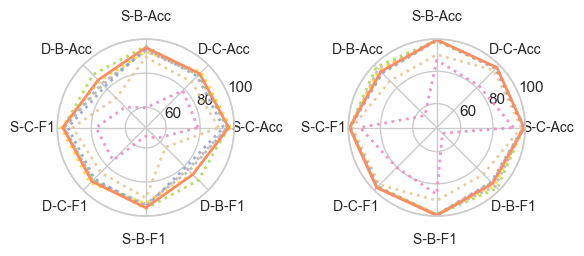

In [402]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assume your dataframe is called df

# Prepare a combined axis column
df['Axis'] = df['Setting'].str[:1] + '-' + df['Modality'].str[:1] + '-' + df['Metric'].str[:3].replace(' ', '')

# Get unique datasets and metrics for subplots
datasets = df['Dataset'].unique()
metrics = df['Metric'].unique()
models = df['Model'].unique()

# Number of axes for radar chart
axes_labels = df['Axis'].unique()
num_axes = len(axes_labels)
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axs = plt.subplots(1, len(datasets), subplot_kw=dict(polar=True), figsize=(6, 8))

# if len(datasets) == 1 and len(metrics) == 1:
#     axs = np.array([[axs]])
# elif len(datasets) == 1 or len(metrics) == 1:
#     axs = axs.reshape(len(datasets), len(metrics))
cmap = matplotlib.colormaps['Set2']
for i, dataset in enumerate(datasets):
    # for j, metric in enumerate(metrics):
    ax = axs[i]
    subset = df[df['Dataset'] == dataset]
    ys = []
    for mi, model in enumerate(models):
        model_data = subset[subset['Model'] == model]
        # Make sure the values follow the axes order
        values = [model_data[model_data['Axis'] == a]['Mean'].values[0] for a in axes_labels]
        ys.extend(values)
        values += values[:1]  # close the circle
        if model != 'NeuroDetour':
            ax.plot(angles, values, label=model, linewidth=2, linestyle=':', alpha=0.85, color=cmap(1-(mi/8)))
        else:
            ax.plot(angles, values, label=model, linewidth=2, linestyle='-', color=cmap(1-(mi/8)))
        # ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axes_labels, fontsize=10)
    # ax.set_title(f"{dataset}", fontsize=14)
    ax.set_ylim(min(ys)-5, 100)

# Legend outside

# plt.legend(models, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
# fig_legend = plt.figure(figsize=(3, 2))
# lines, labels = ax.get_legend_handles_labels()
# fig_legend.legend(lines, labels, loc='center')
# fig_legend.tight_layout()
# fig_legend.savefig("radar_ukb-hcp_legend.svg", bbox_inches='tight')
plt.tight_layout()
plt.savefig('radar_ukb-hcp.svg')
plt.show()


In [408]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

latex_table = r"""
\begin{tabular}{llllllllllll}
\toprule
            &            & \multicolumn{2}{c}{ADNI CORR} & \multicolumn{2}{c}{ADNI BOLD} & \multirow{2}{*}{Rank $\downarrow$} & \multicolumn{2}{c}{OASIS CORR} & \multicolumn{2}{c}{OASIS BOLD} & \multirow{2}{*}{Rank $\downarrow$}\\\cmidrule(lr){3-4}\cmidrule(lr){5-6}\cmidrule(lr){8-9}\cmidrule(lr){10-11}
        &           & static  & dynamic  & static & dynamic & & static & dynamic & static & dynamic &  \\
\midrule
% $\bullet$ Accuracy $\uparrow$ \\
 Acc. $\uparrow$ &     MLP & 79.26$_{\pm10.34}$ & 82.68$_{\pm5.71}$ &  80.67$_{\pm7.26}$ & 82.93$_{\pm6.35}$ & 6.75 & 89.28$_{\pm3.58}$ & 89.32$_{\pm3.18}$ & 88.99$_{\pm3.52}$ & 89.02$_{\pm3.25}$ & 4.00\\
     &            GCN &  {84.22$_{\pm6.92}$} & 83.30$_{\pm6.30}$ &  80.67$_{\pm7.26}$ & 83.53$_{\pm5.39}$ & 3.75 & 88.80$_{\pm2.88}$ & 88.30$_{\pm3.54}$ & 88.27$_{\pm4.87}$ & 88.49$_{\pm3.16}$ & 6.75\\%\midrule
     &            BrainGNN &  82.07$_{\pm6.86}$ & {83.30$_{\pm5.42}$} &  82.07$_{\pm6.86}$ & 83.42$_{\pm6.05}$ & 4.00 & 89.29$_{\pm4.75}$ & {89.65$_{\pm3.31}$} & 87.76$_{\pm4.64}$  & {89.27$_{\pm3.36}$} & 3.25 \\
     &            BNT &  82.81$_{\pm6.47}$ & 83.30$_{\pm6.30}$ &  82.67$_{\pm4.40}$ & {84.33$_{\pm6.99}$} & \underline{2.50} & 89.02$_{\pm3.48}$ & {89.98$_{\pm2.75}$} & 88.75$_{\pm4.36}$ & {89.57$_{\pm3.02}$} & \underline{2.75} \\
     &            BolT &  82.00$_{\pm3.51}$ & 80.34$_{\pm2.82}$ &  81.41$_{\pm7.08}$ & 80.80$_{\pm7.53}$ & 7.00 &          88.30$_{\pm3.77}$ & 88.97$_{\pm3.04}$ & 87.54$_{\pm4.62}$ & 88.50$_{\pm3.35}$ & 6.75 \\%\midrule
      &           Graphormer &  82.74$_{\pm5.89}$ & 83.28$_{\pm5.80}$ &  {83.48$_{\pm5.31}$} & 81.28$_{\pm6.58}$ & 4.50 & 88.55$_{\pm4.22}$ & 88.57$_{\pm3.18}$ & 87.49$_{\pm5.19}$ & 88.98$_{\pm3.26}$ & 7.0 \\
       &          NAGphormer &  82.74$_{\pm5.89}$ & 82.79$_{\pm5.82}$ &  81.33$_{\pm6.09}$ & 82.17$_{\pm5.73}$ & 5.50 & {89.53$_{\pm3.33}$} & 88.64$_{\pm3.85}$ & {89.02$_{\pm3.48}$} & 89.21$_{\pm3.44}$ & 3.0 \\
     &         \modelname{} & {85.56$^{**}_{\pm4.97}$} & {83.82$^{*}_{\pm3.94}$} &  {83.48$_{\pm5.31}$} & {83.68$_{\pm5.64}$} & \textbf{1.25} & {90.01$^{**}_{\pm3.42}$} & {89.49$_{\pm3.33}$} & {89.02$_{\pm3.48}$} & {89.21$_{\pm3.44}$} & \textbf{2.50}\\

\midrule
% $\bullet$ F1 score $\uparrow$ \\
F1 $\uparrow$ &  MLP &  74.72$_{\pm8.67}$ & 77.98$_{\pm5.79}$ &  74.96$_{\pm9.17}$ & 76.75$_{\pm7.08}$ & 7.00 & {87.05$_{\pm5.00}$} & {86.74$_{\pm4.81}$} & 85.27$_{\pm4.82}$ & {85.02$_{\pm5.03}$} & \textbf{2.50} \\
      &   GCN &  78.53$_{\pm9.76}$ & 76.95$_{\pm8.17}$ &  76.19$_{\pm8.50}$ & 77.87$_{\pm5.66}$ & 5.00 & 84.75$_{\pm5.56}$ & 85.71$_{\pm4.10}$ & {85.56$_{\pm5.55}$} & {85.86$_{\pm3.97}$} & 3.75 \\%\midrule
      &   BrainGNN & 76.57$_{\pm10.01}$ & {79.14$_{\pm8.02}$} &  75.11$_{\pm9.69}$ & {78.82$_{\pm6.96}$} & 4.25 & 86.07$_{\pm5.71}$ & 85.12$_{\pm4.90}$ & 84.94$_{\pm5.22}$  & 84.50$_{\pm5.00}$ & 5.50 \\
       &  BNT &  {79.68$_{\pm6.15}$} & 78.71$_{\pm6.67}$ &  80.16$_{\pm8.01}$ & {80.50$_{\pm8.40}$} & \textbf{1.75} & 86.07$_{\pm3.19}$ & {86.73$_{\pm3.57}$} & 85.32$_{\pm4.85}$ & {85.67$_{\pm4.04}$} & 2.75\\
      &   BolT &  79.64$_{\pm4.33}$ & 76.89$_{\pm7.75}$ &  76.68$_{\pm8.77}$ & 77.92$_{\pm8.62}$ & 4.50 & 85.49$_{\pm3.85}$ & 84.91$_{\pm4.76}$ & 84.91$_{\pm4.76}$ & 84.70$_{\pm4.39}$ & 6.25 \\%\midrule
      &   Graphormer &  78.14$_{\pm6.03}$ & 78.29$_{\pm5.22}$ &  {77.78$_{\pm5.51}$} & 76.74$_{\pm6.95}$ & 4.75 & 84.77$_{\pm5.24}$ & 85.67$_{\pm3.72}$ & 85.44$_{\pm4.73}$ & 84.40$_{\pm4.77}$ & 5.75 \\
       &  NAGphormer &  76.57$_{\pm6.67}$ & 76.46$_{\pm6.93}$ &  75.40$_{\pm8.58}$ & 77.80$_{\pm7.01}$ & 6.00 & 85.61$_{\pm4.79}$ & 84.76$_{\pm4.58}$ & 83.87$_{\pm5.02}$ & 84.48$_{\pm4.58}$ & 7.00 \\
      &         \modelname{} & {83.29$^{**}_{\pm4.45}$} & {79.93$^{*}_{\pm5.83}$} &  {77.35$_{\pm7.35}$} & {78.05$_{\pm5.88}$} & \underline{2.00} & {86.37$_{\pm5.03}$} & {86.26$_{\pm4.48}$} & {87.02$^{**}_{\pm3.77}$} & 85.01$_{\pm4.48}$ & \textbf{2.50}\\
"""

# Parsing logic
data = []
current_metric = None
lines = latex_table.split('\n')

for line in lines:
    line = line.strip()
    if not line or line.startswith('\\') or line.startswith('%'):
        # Check for start of rows but skip commands
        pass
    
    # Identify metric
    if 'Acc.' in line:
        current_metric = 'Accuracy'
    elif 'F1' in line:
        current_metric = 'F1 Score'
        
    # Data extraction
    # Looking for lines with "&"
    if '&' in line and (current_metric is not None):
        parts = line.split('&')
        # Clean parts
        parts = [p.strip() for p in parts]
        
        # Model name is in index 1 usually (index 0 is metric name or empty)
        model_name = parts[1].replace('\\modelname{}', 'NeuroDetour').replace('\\', '').replace(' ', '')
        
        # Values
        # Indices:
        # 2: HCPA CORR static
        # 3: HCPA CORR dynamic
        # 4: HCPA BOLD static
        # 5: HCPA BOLD dynamic
        # 6: Rank HCPA
        # 7: UKB CORR static
        # 8: UKB CORR dynamic
        # 9: UKB BOLD static
        # 10: UKB BOLD dynamic
        # 11: Rank UKB
        
        # Helper to parse "96.01$_{\pm0.50}$" or "{96.01$_{\pm0.50}$}"
        def parse_cell(cell):
            # Remove tex formatting
            cell = cell.replace('{', '').replace('}', '').replace('\\', '').replace('$', '')
            is_significant = '*' in cell
            cell = cell.replace('*', '').replace('textbf', '').replace('underline', '')
            
            # Extract mean and std
            if 'pm' in cell:
                # Format: mean_pmstd
                vals = cell.split('pm')
                mean = float(vals[0].split('_')[0].replace('^',''))
                std = float(vals[1])
            else:
                try:
                    mean = float(cell)
                    std = 0.0
                except:
                    mean = np.nan
                    std = 0.0
            return mean, std, is_significant

        # Data Mapping
        mapping = [
            (2, 'ADNI', 'CORR', 'Static'),
            (3, 'ADNI', 'CORR', 'Dynamic'),
            (4, 'ADNI', 'BOLD', 'Static'),
            (5, 'ADNI', 'BOLD', 'Dynamic'),
            (7, 'OASIS', 'CORR', 'Static'),
            (8, 'OASIS', 'CORR', 'Dynamic'),
            (9, 'OASIS', 'BOLD', 'Static'),
            (10, 'OASIS', 'BOLD', 'Dynamic')
        ]
        
        for idx, dataset, modality, setting in mapping:
            if idx < len(parts):
                mean, std, sig = parse_cell(parts[idx])
                data.append({
                    'Metric': current_metric,
                    'Model': model_name,
                    'Dataset': dataset,
                    'Modality': modality,
                    'Setting': setting,
                    'Mean': mean,
                    'Std': std,
                    'Significant': sig,
                    'Rank': float(parts[6].replace('\\', '').replace('textbf', '').replace('underline', '').replace('{','').replace('}','')) if dataset == 'HCPA' else float(parts[11].replace('\\', '').replace('textbf', '').replace('underline', '').replace('{','').replace('}','').replace('%midrule',''))
                })

df = pd.DataFrame(data)

# Print head to verify
print(df.head())
print(df[df['Model'] == 'NeuroDetour'])

     Metric Model Dataset Modality  Setting   Mean    Std  Significant  Rank
0  Accuracy   MLP    ADNI     CORR   Static  79.26  10.34        False   4.0
1  Accuracy   MLP    ADNI     CORR  Dynamic  82.68   5.71        False   4.0
2  Accuracy   MLP    ADNI     BOLD   Static  80.67   7.26        False   4.0
3  Accuracy   MLP    ADNI     BOLD  Dynamic  82.93   6.35        False   4.0
4  Accuracy   MLP   OASIS     CORR   Static  89.28   3.58        False   4.0
       Metric        Model Dataset Modality  Setting   Mean   Std  \
56   Accuracy  NeuroDetour    ADNI     CORR   Static  85.56  4.97   
57   Accuracy  NeuroDetour    ADNI     CORR  Dynamic  83.82  3.94   
58   Accuracy  NeuroDetour    ADNI     BOLD   Static  83.48  5.31   
59   Accuracy  NeuroDetour    ADNI     BOLD  Dynamic  83.68  5.64   
60   Accuracy  NeuroDetour   OASIS     CORR   Static  90.01  3.42   
61   Accuracy  NeuroDetour   OASIS     CORR  Dynamic  89.49  3.33   
62   Accuracy  NeuroDetour   OASIS     BOLD   Static  8

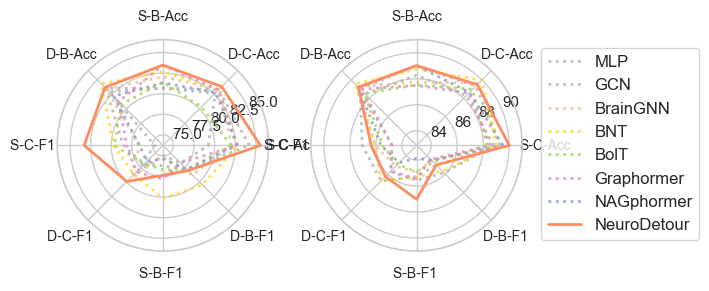

<Figure size 300x200 with 0 Axes>

In [411]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assume your dataframe is called df

# Prepare a combined axis column
df['Axis'] = df['Setting'].str[:1] + '-' + df['Modality'].str[:1] + '-' + df['Metric'].str[:3].replace(' ', '')

# Get unique datasets and metrics for subplots
datasets = df['Dataset'].unique()
metrics = df['Metric'].unique()
models = df['Model'].unique()

# Number of axes for radar chart
axes_labels = df['Axis'].unique()
num_axes = len(axes_labels)
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axs = plt.subplots(1, len(datasets), subplot_kw=dict(polar=True), figsize=(6, 8))

# if len(datasets) == 1 and len(metrics) == 1:
#     axs = np.array([[axs]])
# elif len(datasets) == 1 or len(metrics) == 1:
#     axs = axs.reshape(len(datasets), len(metrics))
cmap = matplotlib.colormaps['Set2']
for i, dataset in enumerate(datasets):
    # for j, metric in enumerate(metrics):
    ax = axs[i]
    subset = df[df['Dataset'] == dataset]
    ys = []
    for mi, model in enumerate(models):
        model_data = subset[subset['Model'] == model]
        # Make sure the values follow the axes order
        values = [model_data[model_data['Axis'] == a]['Mean'].values[0] for a in axes_labels]
        ys.extend(values)
        values += values[:1]  # close the circle
        if model != 'NeuroDetour':
            ax.plot(angles, values, label=model, linewidth=2, linestyle=':', alpha=0.85, color=cmap(1-(mi/8)))
        else:
            ax.plot(angles, values, label=model, linewidth=2, linestyle='-', color=cmap(1-(mi/8)))
        # ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(axes_labels, fontsize=10)
    # ax.set_title(f"{dataset}", fontsize=14)
    ax.set_ylim(min(ys)-1, max(ys)+1)

# Legend outside

plt.legend(models, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
fig_legend = plt.figure(figsize=(3, 2))
lines, labels = ax.get_legend_handles_labels()
fig_legend.legend(lines, labels, loc='center')
fig_legend.tight_layout()
fig_legend.savefig("radar_adni-oasis_legend.svg", bbox_inches='tight')
plt.tight_layout()
# plt.savefig('radar_adni-oasis.svg')
plt.show()


In [436]:
models

array(['MLP', 'GCN', 'BrainGNN', 'BNT', 'BolT', 'Graphormer',
       'NAGphormer', 'NeuroDetour'], dtype=object)

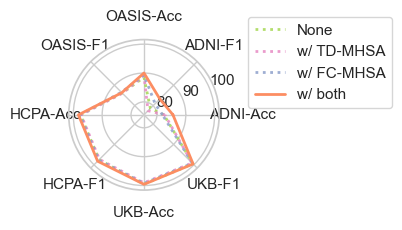

In [454]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================
# Data from the LaTeX table
# ============================

labels = ["ADNI-Acc", "ADNI-F1", "OASIS-Acc", "OASIS-F1", "HCPA-Acc", "HCPA-F1", "UKB-Acc", "UKB-F1"]

methods = ["None", "w/ TD-MHSA", "w/ FC-MHSA", "w/ both"]

means = np.array([
    [82.42, 78.65, 88.52, 86.19, 97.53, 97.53, 99.53, 99.53],
    [82.74, 77.51, 89.05, 86.11, 97.33, 97.34, 99.10, 99.10],
    [81.93, 80.97, 89.31, 86.58, 97.72, 97.72, 99.25, 99.25],
    [85.56, 83.29, 90.01, 86.37, 98.23, 98.23, 99.59, 99.59],
])

stds = np.array([
    [5.98, 7.37, 3.48, 3.81, 0.50, 0.51, 0.22, 0.22],
    [7.88, 9.39, 3.99, 4.32, 0.44, 0.43, 0.13, 0.13],
    [3.25, 4.20, 4.36, 5.87, 0.34, 0.34, 0.18, 0.18],
    [4.97, 4.45, 3.42, 5.03, 0.45, 0.45, 0.21, 0.21],
])

# Radar setup
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Extend mean/std to close radar
means_c = np.concatenate([means, means[:, :1]], axis=1)
stds_c = np.concatenate([stds, stds[:, :1]], axis=1)

# Colormap reversed Set2
cmap = matplotlib.colormaps['Set2']
# cmap = cm.get_cmap("Set2_r")
# colors = [cmap(i / len(methods)) for i in range(len(methods))]

# Plot
fig = plt.figure(figsize=(3, 3))
ax = plt.subplot(111, polar=True)
ys = []
for i, method in enumerate(methods):
    mean = means_c[i]
    std = stds_c[i]
    upper = mean + std
    lower = mean - std
    ys.extend(mean)
    # Shaded std confidence band
    # ax.fill(angles, upper, alpha=0.12, color=colors[i])
    # ax.fill(angles, lower, alpha=1.0, color='white')
    # ax.fill_between(angles, lower, upper, alpha=0.15, color=colors[i])

    # Mean line
    # ax.plot(angles, mean, linewidth=2, label=method, color=colors[i])
    if method != 'w/ both':
        ax.plot(angles, mean, label=method, linewidth=2, linestyle=':', alpha=0.85, color=cmap(1-((i + 4)/8)))
    else:
        ax.plot(angles, mean, label=method, linewidth=2, linestyle='-', color=cmap(1-((i + 4)/8)))

# Aesthetic settings
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
# ax.set_yticks([])
# ax.set_title("Radar Chart with Mean ± Std (Reversed Set2 colormap)", fontsize=15, pad=20)
plt.tight_layout()
ax.legend(loc='upper right', bbox_to_anchor=(2.2, 1.2))
ax.set_ylim(min(ys)-2, max(ys)+2)

plt.savefig("radar_ablation.pdf", bbox_inches='tight')
plt.show()


In [433]:
cmap()

(0.7019607843137254, 0.7019607843137254, 0.7019607843137254, 1.0)